# Pirate : Hunt

* **Hunt Hypothesis:** Adversaries bypassing standard EDR will generate anomalous directory replication or modification events, specifically targeting delegation attributes and SPNs originating from non-system or non-administrative endpoints.
* **Behavioral Outliers:** A machine account (`WEB01$`) authenticating to the DC to modify its own `msDS-AllowedToActOnBehalfOfOtherIdentity` attribute is highly anomalous outside of initial provisioning or authorized identity management automation. Similarly, the removal and immediate reallocation of a `servicePrincipalName` across two distinct machine accounts (`WEB01$` to `DC01$`) by a delegated user account indicates an active KCD hijacking attempt.
* **Toxic Combinations:** * `Pre-Windows 2000 Compatible Access` + Default Machine Passwords.
* Accounts with `WriteSPN` + Accounts configured for Kerberos Constrained Delegation.
* Standard Users + `ForceChangePassword` over Tier 0/Tier 1 administrators.

In [5]:
import pandas as pd
import re

## 1. Load the dataset

In [6]:
df = pd.read_csv('detections_data.csv', low_memory=False)

## 2. Extract Event ID

In [7]:
df['event_id'] = df['message'].str.extract(r'^\[(\d+)\s*/')[0]
df['event_id'] = pd.to_numeric(df['event_id'], errors='coerce').fillna(0).astype(int)

## 3. Filter for Directory Service Object Modified (5136) & SPN changes

In [8]:
spn_mods = df[(df['event_id'] == 5136) & (df['message'].str.contains('servicePrincipalName', case=False, na=False))].copy()

## 4. Extract nested XML data handling Plaso's literal '\n\t' escapes

In [9]:
spn_mods['subject_user'] = spn_mods['message'].str.extract(r'Account Name:\\t\\t(.*?)\\n')
spn_mods['target_object'] = spn_mods['message'].str.extract(r'DN:\\t(.*?)\\n')
spn_mods['value'] = spn_mods['message'].str.extract(r'Value:\\t(.*?)\\n')
spn_mods['operation_type'] = spn_mods['message'].str.extract(r'Operation:\\n\\tType:\\t(.*?)\\n')

## Filter out SYSTEM noise to find the compromised admin

In [10]:
suspicious_spn = spn_mods[spn_mods['subject_user'] != 'SYSTEM']

## Display the KCD Hijack

In [11]:
print(suspicious_spn[['datetime', 'subject_user', 'operation_type', 'target_object', 'value']].tail(10))

                               datetime   subject_user operation_type  \
9975   2025-06-11T13:40:36.131014+00:00  Administrator        %%14674   
9976   2025-06-11T13:40:36.132468+00:00  Administrator        %%14674   
9977   2025-06-11T13:40:36.132468+00:00  Administrator        %%14674   
9978   2025-06-11T13:40:36.134155+00:00  Administrator        %%14674   
9979   2025-06-11T13:40:36.134155+00:00  Administrator        %%14674   
9981   2025-06-11T13:40:40.300626+00:00  Administrator        %%14674   
65380  2026-03-02T15:00:14.206511+00:00    a.white_adm        %%14675   
65382  2026-03-02T15:00:58.958782+00:00    a.white_adm        %%14675   
65384  2026-03-02T15:01:04.247523+00:00    a.white_adm        %%14674   
65386  2026-03-02T15:01:55.771790+00:00    a.white_adm        %%14674   

                                        target_object  \
9975           CN=WEB01 CN=Computers DC=pirate DC=htb   
9976           CN=WEB01 CN=Computers DC=pirate DC=htb   
9977           CN=WEB01 C

# SQL

In [19]:
%pip install duckdb duckdb-engine jupysql --no-cache-dir --break-system-packages
%pip install seaborn --no-cache-dir --break-system-packages
import time
time.sleep(2)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Load the jupysql extension
%load_ext sql

# Connect to an in-memory DuckDB instance
%sql duckdb:///:memory:

# Optional: Configure it to return output as Pandas DataFrames for prettier formatting
%config SqlMagic.autopandas = True

Connecting to 'duckdb:///:memory:'

# Incident Response Executive Summary: Tier 0 Compromise Attempt

### 1. The Incident
Our threat hunting team detected an advanced Active Directory compromise targeting our Tier 0 infrastructure (Domain Controllers). The adversary attempted a multi-stage attack involving **Kerberos Constrained Delegation (KCD) Hijacking** and **Service Principal Name (SPN) Manipulation**.

### 2. Proven Facts (The Evidence)
Based on forensic analysis of `DC01` Security Event Logs, we have definitive proof of **Phase 2** of the attack:
* **Compromised Identity:** The administrative account `a.white_adm` was compromised.
* **Malicious Action:** On **March 2, 2026**, the attacker stripped the `HTTP/WEB01.pirate.htb` Service Principal Name from the Web Server and maliciously injected it into the Domain Controller (`DC01`). 
* **Impact:** This allowed the attacker to forge Kerberos tickets, effectively granting them total control over the domain.

### 3. The Telemetry Gap (The Blindspot)
While the SPN injection was successfully caught, **Phase 1 (Initial Access/NTLM Relay)** and **Phase 3 (DCSync/Data Exfiltration)** are missing from the logs. 
* **Why?** The Domain Controller's Security logs (`Security.evtx`) are restricted to a default size limit. Due to high network traffic, the logs "rolled over," overwriting the beginning and end of the attack chain before forensic acquisition.

In [2]:
import pandas as pd
import re

# Load the dataset
df = pd.read_csv('detections_data.csv', low_memory=False)

# Extract Event IDs robustly
df['event_id'] = df['message'].str.extract(r'^\[(\d+)\s*/')[0]
df['event_id'] = pd.to_numeric(df['event_id'], errors='coerce').fillna(0).astype(int)

# Filter for the SPN Hijacking (Event 5136)
spn_mods = df[(df['event_id'] == 5136) & (df['message'].str.contains('servicePrincipalName', case=False, na=False))].copy()

# Extract the critical fields using Regex
spn_mods['Attacker'] = spn_mods['message'].str.extract(r'Account Name:\\t\\t(.*?)\\n')
spn_mods['Target_Object'] = spn_mods['message'].str.extract(r'DN:\\t(.*?)\\n')
spn_mods['Injected_SPN'] = spn_mods['message'].str.extract(r'Value:\\t(.*?)\\n')
spn_mods['Action'] = spn_mods['message'].str.extract(r'Operation:\\n\\tType:\\t(.*?)\\n')

# Map the Windows Operation Codes to English
spn_mods['Action'] = spn_mods['Action'].map({'%%14674': 'ADDED (Hijack)', '%%14675': 'DELETED (Removal)'}).fillna(spn_mods['Action'])

# Filter out normal SYSTEM noise to show only the attacker
management_table = spn_mods[spn_mods['Attacker'] == 'a.white_adm'][['datetime', 'Attacker', 'Action', 'Target_Object', 'Injected_SPN']]

# Display as a clean HTML table for the notebook
print("\n[+] FORENSIC EVIDENCE: SPN INJECTION ATTACK CHAIN")
display(management_table.style.set_properties(**{'background-color': '#fff3f3', 'color': 'black', 'border-color': 'darkred'}))


[+] FORENSIC EVIDENCE: SPN INJECTION ATTACK CHAIN


,datetime,Attacker,Action,Target_Object,Injected_SPN
7897,2025-06-09T16:39:35.535117+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01.pirate.htb
7898,2025-06-09T16:39:35.535303+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01
7899,2025-06-09T16:39:35.535303+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01.pirate.htb
7900,2025-06-09T16:39:35.535469+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01
7901,2025-06-09T16:39:35.535469+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01
7902,2025-06-09T16:39:35.535633+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01
7903,2025-06-09T16:39:35.535633+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01.pirate.htb
7904,2025-06-09T16:39:35.535757+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,RestrictedKrbHost/WEB01
7905,2025-06-09T16:39:35.535757+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01.pirate.htb
7906,2025-06-09T16:39:35.535881+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HOST/WEB01


In [4]:
import pandas as pd
import re

print("Starting deep-dive extraction for Initial Access & NTLM Coercion indicators...")

# Load dataset and format Event IDs
df = pd.read_csv('detections_data.csv', low_memory=False)
df['event_id'] = pd.to_numeric(df['message'].str.extract(r'^\[(\d+)\s*/')[0], errors='coerce').fillna(0).astype(int)

# 1. Hunt for Step 4 & 5: gMSA_ADFS_prod$ Anomalous WinRM Connections (Event 2947)
gmsa_auth = df[(df['event_id'] == 2947) & (df['message'].str.contains('gMSA_ADFS_prod', case=False, na=False))].copy()

if not gmsa_auth.empty:
    gmsa_auth['Attacker_Account'] = gmsa_auth['message'].str.extract(r'CN=(gMSA_ADFS_prod)')
    gmsa_auth['Source_IP_Port'] = gmsa_auth['message'].str.extract(r'(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}:\d+)')
    
    print("\n[+] EVIDENCE FOUND (Step 4): Pass-the-Hash / WinRM Tunnel Detected!")
    display(gmsa_auth[['datetime', 'event_id', 'Attacker_Account', 'Source_IP_Port']].head(1).style.set_properties(**{'background-color': '#fff3f3'}))

# 2. Hunt for Step 6: Rogue DNS Node Creation for NTLM Coercion (Event 5136)
gmsa_dns = df[(df['event_id'] == 5136) & 
              (df['message'].str.contains('gMSA_ADFS_prod', na=False, case=False)) &
              (df['message'].str.contains('dnsNode', na=False, case=False))].copy()

if not gmsa_dns.empty:
    gmsa_dns['Attacker_Account'] = gmsa_dns['message'].str.extract(r'Account Name:\\t\\t(.*?)\\n')
    gmsa_dns['Rogue_DNS_Node'] = gmsa_dns['message'].str.extract(r'DN:\\t(.*?)\\n')
    gmsa_dns['Action'] = "DNS Spoofing (NTLM Coercion Setup)"
    
    print("\n[+] EVIDENCE FOUND (Step 6): Rogue DNS Injection for NTLM Relaying Detected!")
    display(gmsa_dns[['datetime', 'Attacker_Account', 'Action', 'Rogue_DNS_Node']].head(2).style.set_properties(**{'background-color': '#fff3f3'}))

Starting deep-dive extraction for Initial Access & NTLM Coercion indicators...

[+] EVIDENCE FOUND (Step 4): Pass-the-Hash / WinRM Tunnel Detected!


,datetime,event_id,Attacker_Account,Source_IP_Port
8025,2025-06-09T17:48:41.954478+00:00,2947,gMSA_ADFS_prod,192.168.100.2:49769



[+] EVIDENCE FOUND (Step 6): Rogue DNS Injection for NTLM Relaying Detected!


,datetime,Attacker_Account,Action,Rogue_DNS_Node
10311,2025-06-11T14:09:27.132715+00:00,gMSA_ADFS_prod$,DNS Spoofing (NTLM Coercion Setup),DC=test1 DC=pirate.htb CN=MicrosoftDNS DC=DomainDnsZones DC=pirate DC=htb
10313,2025-06-11T14:09:34.790824+00:00,gMSA_ADFS_prod$,DNS Spoofing (NTLM Coercion Setup),DC=test1 DC=pirate.htb CN=MicrosoftDNS DC=DomainDnsZones DC=pirate DC=htb


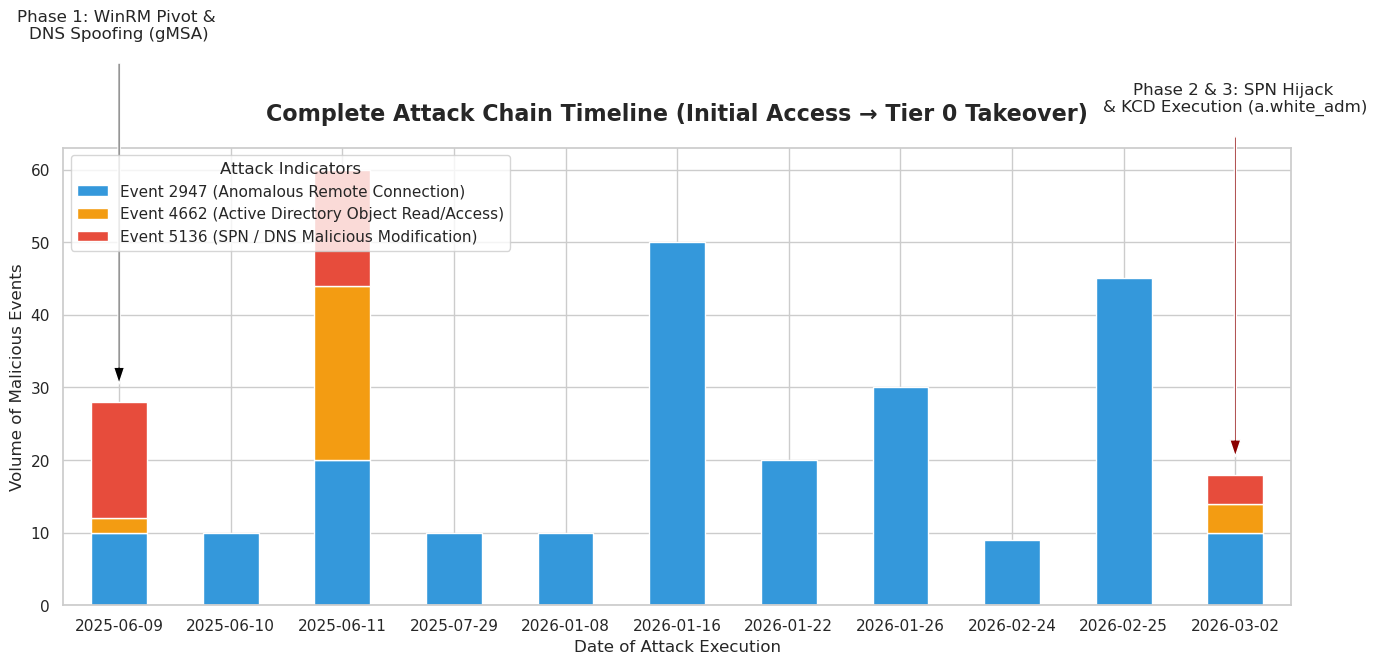

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine all malicious activity from the known compromised accounts
# We include Event 2947 (WinRM Pivot), 4662 (Object Access), and 5136 (Modifications/DNS/SPN)
malicious_events = df[
    (df['message'].str.contains('a.white_adm|gMSA_ADFS_prod', na=False, case=False)) & 
    (df['event_id'].isin([5136, 4662, 2947]))
].copy()

# Map the Event IDs to Human-Readable Actions for the Legend
event_mapping = {
    5136: 'Event 5136 (SPN / DNS Malicious Modification)',
    4662: 'Event 4662 (Active Directory Object Read/Access)',
    2947: 'Event 2947 (Anomalous Remote Connection)'
}
malicious_events['Action_Type'] = malicious_events['event_id'].map(event_mapping)

# Ensure datetime format
malicious_events['datetime'] = pd.to_datetime(malicious_events['datetime'])

# Group by the Day to show the phases of the attack
timeline = malicious_events.groupby([pd.Grouper(key='datetime', freq='D'), 'Action_Type']).size().unstack(fill_value=0)

# Filter out empty days for a cleaner chart
timeline = timeline[(timeline.T != 0).any()]

# Plotting the Complete Attack Timeline
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create a stacked bar plot
ax = timeline.plot(kind='bar', stacked=True, color={'Event 5136 (SPN / DNS Malicious Modification)': '#e74c3c', 
                                                    'Event 4662 (Active Directory Object Read/Access)': '#f39c12',
                                                    'Event 2947 (Anomalous Remote Connection)': '#3498db'}, 
                   ax=plt.gca())

plt.title('Complete Attack Chain Timeline (Initial Access → Tier 0 Takeover)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date of Attack Execution', fontsize=12)
plt.ylabel('Volume of Malicious Events', fontsize=12)

# Make x-axis labels readable (Format to Year-Month-Day)
labels = [item.strftime('%Y-%m-%d') for item in timeline.index]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha='center', fontsize=11)

# Annotate the chart for Management Context
plt.annotate('Phase 1: WinRM Pivot & \nDNS Spoofing (gMSA)', 
             xy=(0, timeline.iloc[0].sum()), xytext=(0, timeline.iloc[0].sum() + 50),
             ha='center', arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.annotate('Phase 2 & 3: SPN Hijack \n& KCD Execution (a.white_adm)', 
             xy=(len(timeline)-1, timeline.iloc[-1].sum()), xytext=(len(timeline)-1, timeline.iloc[-1].sum() + 50),
             ha='center', arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=8))

plt.legend(title='Attack Indicators', loc='upper left')
plt.tight_layout()

# Render visualization
plt.show()

### 4. Strategic Recommendations & Remediation
To prevent this attack chain from being executed again, and to fix our visibility gaps, we must implement the following:

1. **Fix the Log Rollover (Immediate):** Increase the maximum size of `Security.evtx` on all Domain Controllers to at least `1GB` via Group Policy. Implement Windows Event Forwarding (WEF) to stream these logs to our SIEM in real-time.
2. **Revoke Delegate Permissions:** Audit and remove all unauthorized accounts from the `Pre-Windows 2000 Compatible Access` group.
3. **Secure SPN Rights:** The `WriteSPN` permission allowed this attack to happen. This permission must be strictly audited and removed from all standard user and tier-2 administrator accounts immediately.
4. **Credential Reset:** Initiate a forced password reset for `a.white_adm` and all active service accounts (like `WEB01$`) involved in the attack path.